## Target: Map
## Input: 5 time steps of 30 minutes (up to 2 hours before)

## Imports

In [193]:
from tensorflow.keras import layers, models                                             # type: ignore
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout                                # type: ignore

In [194]:
lead_time = 1

In [195]:
resolution = 11

## Read data

In [196]:
test_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/test-Dakar-map-features-many-timesteps-30min-lt{lead_time}-2h-before.csv", index_col=False)
test_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/test-Dakar-map-target-many-timesteps-30min-lt{lead_time}-2h-before.csv", index_col=False)

train_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/train-Dakar-map-features-many-timesteps-30min-lt{lead_time}-2h-before.csv", index_col=False)
train_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/train-Dakar-map-target-many-timesteps-30min-lt{lead_time}-2h-before.csv", index_col=False)

In [197]:
raw_test_X = test_data_X
raw_train_X, raw_validation_X, train_y, validation_y = train_test_split(train_data_X, train_data_y, test_size=0.3, random_state=12)

In [198]:
# Initial headers for time periods
t0 = "year,month,day,hour,minute,"
t30 = "year_30,month_30,day_30,hour_30,minute_30,"
t60 = "year_60,month_60,day_60,hour_60,minute_60,"
t90 = "year_90,month_90,day_90,hour_90,minute_90,"
t120 = "year_120,month_120,day_120,hour_120,minute_120,"

# Initialize empty strings for loc, wp, ds, sz for t0 (current), t30, t60, t90, and t120
loc = wp = ds = sz = "" 
loc_30 = wp_30 = ds_30 = sz_30 = "" 
loc_60 = wp_60 = ds_60 = sz_60 = "" 
loc_90 = wp_90 = ds_90 = sz_90 = "" 
loc_120 = wp_120 = ds_120 = sz_120 = "" 

# Loop to generate the string for each time period (current, +30, +60, +90, +120 minutes)
for i in range(1, 6):
    # For the current time (t0)
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    
    # For t30 (30 minutes later)
    loc_30 += f"lat{i}_30,lon{i}_30,"
    wp_30 += f"wp{i}_30,"
    ds_30 += f"ds{i}_30,"
    sz_30 += f"size{i}_30,"
    
    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    ds_60 += f"ds{i}_60,"
    sz_60 += f"size{i}_60,"
    
    # For t90 (90 minutes later)
    loc_90 += f"lat{i}_90,lon{i}_90,"
    wp_90 += f"wp{i}_90,"
    ds_90 += f"ds{i}_90,"
    sz_90 += f"size{i}_90,"
    
    # For t120 (120 minutes later)
    loc_120 += f"lat{i}_120,lon{i}_120,"
    wp_120 += f"wp{i}_120,"
    ds_120 += f"ds{i}_120,"
    sz_120 += f"size{i}_120,"

# Concatenate all headers for t0, t30, t60, t90, t120
headers = (t0 + loc + wp + ds + sz + 
           t30 + loc_30 + wp_30 + ds_30 + sz_30 + 
           t60 + loc_60 + wp_60 + ds_60 + sz_60 + 
           t90 + loc_90 + wp_90 + ds_90 + sz_90 + 
           t120 + loc_120 + wp_120 + ds_120 + sz_120)

print(headers)


year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,lon3,lat4,lon4,lat5,lon5,wp1,wp2,wp3,wp4,wp5,ds1,ds2,ds3,ds4,ds5,size1,size2,size3,size4,size5,year_30,month_30,day_30,hour_30,minute_30,lat1_30,lon1_30,lat2_30,lon2_30,lat3_30,lon3_30,lat4_30,lon4_30,lat5_30,lon5_30,wp1_30,wp2_30,wp3_30,wp4_30,wp5_30,ds1_30,ds2_30,ds3_30,ds4_30,ds5_30,size1_30,size2_30,size3_30,size4_30,size5_30,year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,size1_60,size2_60,size3_60,size4_60,size5_60,year_90,month_90,day_90,hour_90,minute_90,lat1_90,lon1_90,lat2_90,lon2_90,lat3_90,lon3_90,lat4_90,lon4_90,lat5_90,lon5_90,wp1_90,wp2_90,wp3_90,wp4_90,wp5_90,ds1_90,ds2_90,ds3_90,ds4_90,ds5_90,size1_90,size2_90,size3_90,size4_90,size5_90,year_120,month_120,day_120,hour_120,minute_120,lat1_120,lon1_120,lat2_120,lon2_120,lat3_120,lon3_120,lat4_120,lon4_120,lat5_120,lon5_120,wp1_1

## Preprocessing

In [199]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [200]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [201]:
# Concatenate headers for wp, sz, and ds across time periods with updated intervals
to_scale = f"{wp}{wp_30}{wp_60}{wp_90}{wp_120}{sz}{sz_30}{sz_60}{sz_90}{sz_120}{ds}{ds_30}{ds_60}{ds_90}{ds_120}".rstrip(',')

# Concatenate headers for time variables with updated intervals
t = f"{t0}{t30}{t60}{t90}{t120}".rstrip(',')

print(to_scale)
print(t)


wp1,wp2,wp3,wp4,wp5,wp1_30,wp2_30,wp3_30,wp4_30,wp5_30,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,wp1_90,wp2_90,wp3_90,wp4_90,wp5_90,wp1_120,wp2_120,wp3_120,wp4_120,wp5_120,size1,size2,size3,size4,size5,size1_30,size2_30,size3_30,size4_30,size5_30,size1_60,size2_60,size3_60,size4_60,size5_60,size1_90,size2_90,size3_90,size4_90,size5_90,size1_120,size2_120,size3_120,size4_120,size5_120,ds1,ds2,ds3,ds4,ds5,ds1_30,ds2_30,ds3_30,ds4_30,ds5_30,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,ds1_90,ds2_90,ds3_90,ds4_90,ds5_90,ds1_120,ds2_120,ds3_120,ds4_120,ds5_120
year,month,day,hour,minute,year_30,month_30,day_30,hour_30,minute_30,year_60,month_60,day_60,hour_60,minute_60,year_90,month_90,day_90,hour_90,minute_90,year_120,month_120,day_120,hour_120,minute_120


In [202]:
def prepare(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t.split(',')[:-1])
    return df

### Transforming

In [203]:
transform = True
if transform:
    train_X = prepare(raw_train_X)
    validation_X = prepare(raw_validation_X)
    test_X = prepare(raw_test_X)

### Scaling

In [204]:
scaler = StandardScaler()
std_X_train = scaler.fit_transform(train_X)
std_X_val = scaler.transform(validation_X)
std_X_test = scaler.transform(test_X)

In [205]:
x_train = std_X_train.reshape(len(train_X), 5, 30)
y_train = tf.reshape(train_y, (len(train_y), resolution, resolution))

x_val = std_X_val.reshape(len(validation_X), 5, 30)
y_val = tf.reshape(validation_y, (len(validation_y), resolution, resolution))

x_test = std_X_test.reshape(len(test_X), 5, 30)
y_test = tf.reshape(test_data_y, (len(test_data_y), resolution, resolution))

In [206]:
y_test.shape

TensorShape([13434, 11, 11])

### Creating the model 

In [207]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(5, 30)),
  LSTM(20, activation="relu"),
  tf.keras.layers.Dense(32, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dense(resolution * resolution, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution, 1)),
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution)),
])

In [208]:
cl_thresholds = 0.3

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]

In [209]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

In [210]:
"""l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:  
  layer.kernel_regularizer = l1_reg"""

'l1_reg = tf.keras.regularizers.L1(0.1)\nfor layer in model.layers[:]:  \n  layer.kernel_regularizer = l1_reg'

In [211]:
optimizer = Adam(clipvalue=1.0, learning_rate=1e-3)
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.AUC(name='prc', curve='PR')])

In [212]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 20)             │         4,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 121)            │         3,993 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_10 (Reshape)            │ (None, 11, 11, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 1)      │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_11 (Reshape)            │ (None, 11, 11)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,098 (35.54 KB)

 Trainable params: 9,098 (35.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=500,                           
                          batch_size = 1024,         
                          callbacks = [early_stopping],
                          validation_data=(x_val, y_val)
                        )

Epoch 1/500


36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.6284 - prc: 0.1565 - val_loss: 0.4232 - val_prc: 0.2599
Epoch 2/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.3854 - prc: 0.3128 - val_loss: 0.3388 - val_prc: 0.4488
Epoch 3/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.3365 - prc: 0.4624 - val_loss: 0.3213 - val_prc: 0.5003
Epoch 4/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.3184 - prc: 0.4990 - val_loss: 0.3105 - val_prc: 0.5310
Epoch 5/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.3090 - prc: 0.5362 - val_loss: 0.3017 - val_prc: 0.5602
Epoch 6/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.2995 - prc: 0.5657 - val_loss: 0.2935 - val_prc: 0.5864
Epoch 7/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.2942 - prc: 0.5857 - val_loss: 0.2859 - val_prc: 0.6037
Epoch 8/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.2846 - prc: 0.6088 - val_loss: 0.2796 - val_prc: 0.6205
Epoch 9/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.2788 

### Save model

In [171]:
dump(scaler, f'Dakar-map-lt{lead_time}-lstm-2h-before.bin', compress=True)
model.save(f'Dakar-map-lt{lead_time}-lstm-2h-before.keras')

In [172]:
n_test = test_data_y.shape[0]

In [173]:
pred_y_train = model.predict(x_train).flatten()
pred_y_test = model.predict(x_test).flatten()

788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [174]:
idx = []
for i in range(y_test.shape[0]):
    idx.append(np.mean(y_test[i]))

In [175]:
idx_max = np.argmax(idx)

In [176]:
y_test[idx_max]

<tf.Tensor: shape=(11, 11), dtype=float64, numpy=
array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])>

In [177]:
raw_test_X.iloc[idx_max, :]

year       2020.00
month         9.00
day           5.00
hour         17.00
minute       15.00
            ...   
ds1_120      25.71
ds2_120      42.15
ds3_120      48.27
ds4_120      50.70
ds5_120      75.29
Name: 2260, Length: 150, dtype: float64

In [178]:
pred_y_test.reshape(n_test, resolution, resolution)[idx_max]

array([[0.3694578 , 0.33820924, 0.29093045, 0.34435597, 0.24856904,
        0.30733782, 0.21809137, 0.18498288, 0.20812126, 0.1919817 ,
        0.20243314],
       [0.28094813, 0.30001327, 0.32950923, 0.2865492 , 0.23405646,
        0.21904808, 0.20978317, 0.18319169, 0.18984802, 0.17484467,
        0.16541311],
       [0.29442167, 0.28827897, 0.29858413, 0.2623817 , 0.25326177,
        0.26013148, 0.24593338, 0.19303283, 0.18267539, 0.18468022,
        0.19437379],
       [0.29753265, 0.28483042, 0.23358662, 0.22874235, 0.24710198,
        0.26604402, 0.26882303, 0.22063571, 0.1844378 , 0.16450231,
        0.21072248],
       [0.32479265, 0.35098198, 0.35126033, 0.2300939 , 0.23416926,
        0.225344  , 0.22133845, 0.21423967, 0.18400696, 0.14085211,
        0.18909922],
       [0.31706795, 0.33346534, 0.4376609 , 0.40142763, 0.36400732,
        0.2845647 , 0.22759175, 0.23481607, 0.18897317, 0.16766301,
        0.17365962],
       [0.3106387 , 0.31294504, 0.43748888, 0.45920652, 0.

## ROC

In [179]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [180]:
auc_train = roc_auc_score(y_train.numpy().flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.numpy().flatten(), pred_y_test)

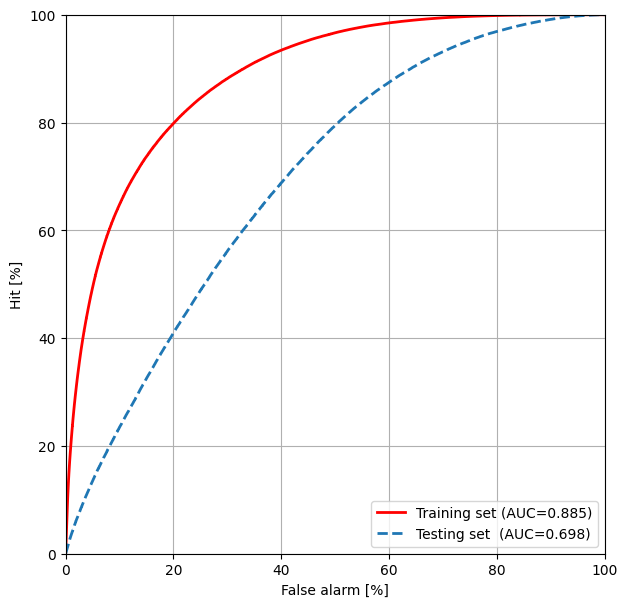

In [181]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.numpy().flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.numpy().flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Reliability diagram

In [182]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

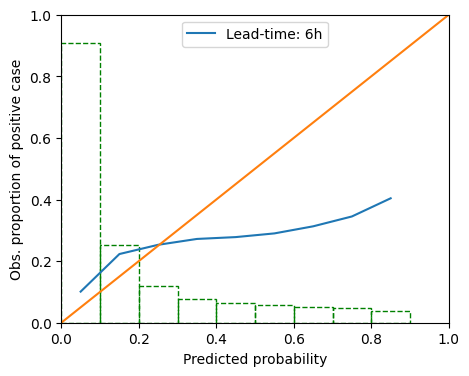

In [183]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.numpy().flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: {lead_time}h")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [184]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [185]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [186]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [187]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [188]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [189]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

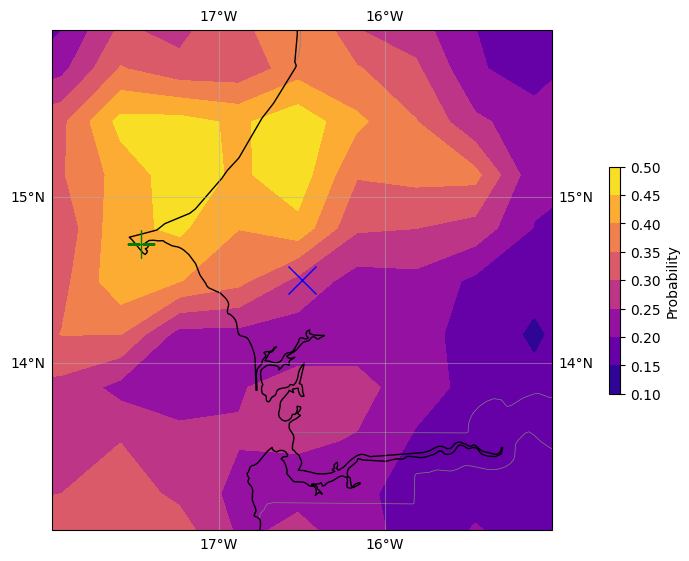

In [190]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[idx_max], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

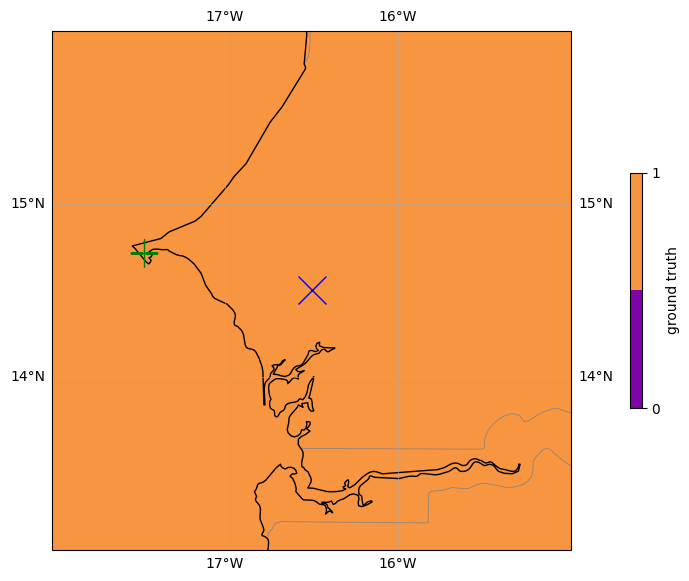

In [191]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, y_test[idx_max], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()